In [12]:

#%pip install mpld3
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:

df = pd.read_csv("../data/processed/311_noise_cleaned.csv", parse_dates=["Created Date"])

In [3]:
# Label each complaint by COVID era for use in the analyses below
def covid_era(d):
    if d < pd.Timestamp('2020-03-01'):
        return 'Pre-COVID'
    elif d < pd.Timestamp('2021-07-01'):
        return 'Lockdown'
    else:
        return 'Post-COVID'

df['Era'] = df['Created Date'].map(covid_era)

complaint types

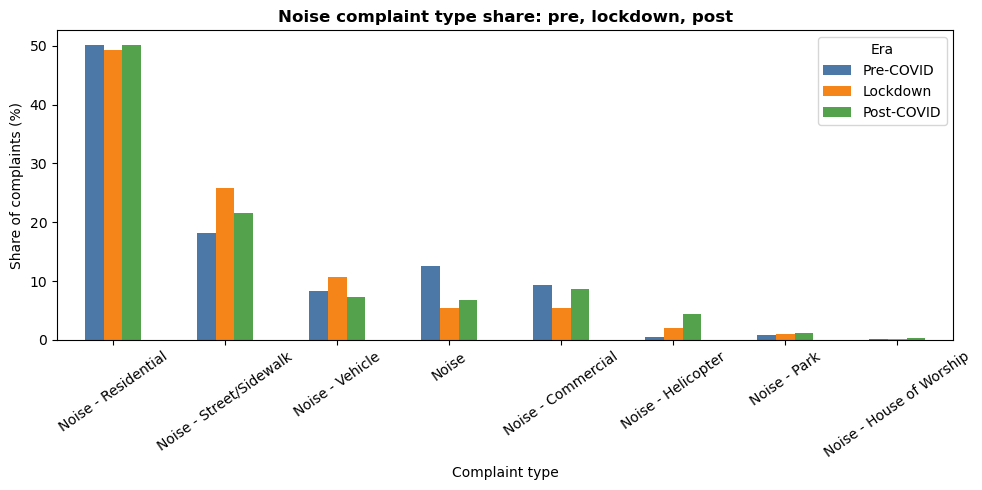

In [15]:
type_col = 'Complaint Type'
era_focus = df[df['Era'].isin(['Pre-COVID', 'Lockdown', 'Post-COVID'])]

share = (
    era_focus.groupby(['Era', type_col]).size()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: s / s.sum() * 100)
    .unstack(fill_value=0)
 )

top_types = (
    share.loc['Pre-COVID'] + share.loc['Lockdown'] + share.loc['Post-COVID']
 ).sort_values(ascending=False).head(8).index
plot_df = share[top_types].T[['Pre-COVID', 'Lockdown', 'Post-COVID']]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_title('Noise complaint type share: pre, lockdown, post', fontweight='bold')
ax.set_ylabel('Share of complaints (%)')
ax.set_xlabel('Complaint type')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Era')
plt.tight_layout()
plt.show()

In [16]:
import plotly.express as px

# plot_df is already in the right format: complaint types as index, eras as columns
fig = px.bar(
    plot_df,
    x=plot_df.index,
    y=['Pre-COVID', 'Lockdown', 'Post-COVID'],
    labels={'value': 'Share of complaints (%)', 'x': 'Complaint type', 'variable': 'Era'},
    barmode='group',
    color_discrete_sequence=['#4c78a8', '#f58518', '#54a24b'],
    title='Noise complaint type share: pre, lockdown, post'
)
fig.update_layout(xaxis_tickangle=35)
fig.write_html("../website/types_of_complaints.html")

Sub-lead: A brief paragraph explaining how the city transitioned from pre-2020 levels to a permanent "New Normal"

Average complaints per month by era:
Era
Pre-COVID     37333
Lockdown      69074
Post-COVID    62824

Lockdown vs pre:   +85.0%
Post-COVID vs pre: +68.3%


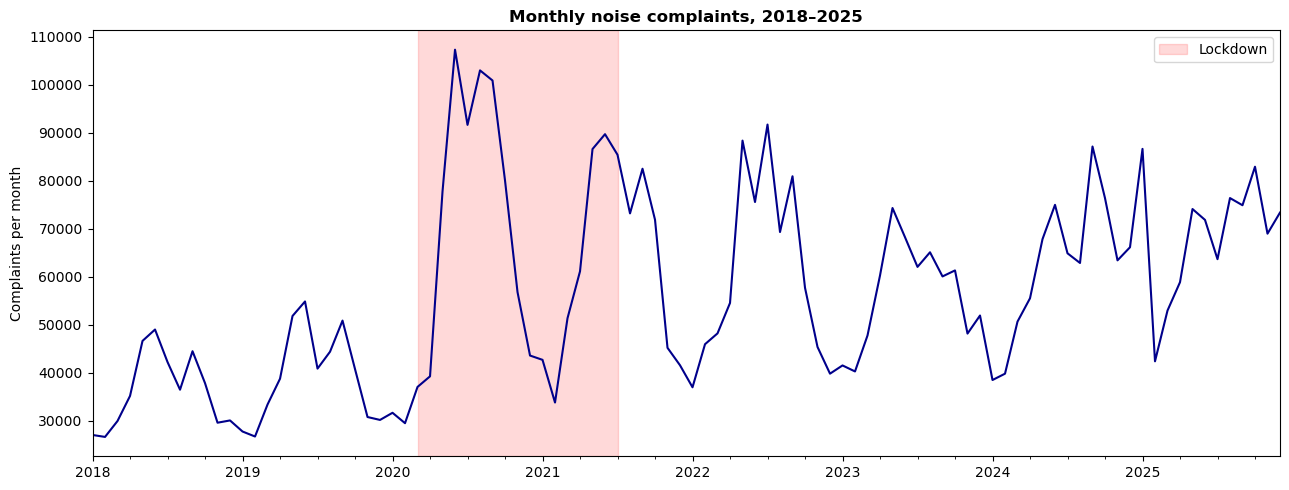

In [17]:
# 1 & 2: monthly complaint rate by era
monthly = df.set_index('Created Date').resample('MS').size()
era_monthly = df.groupby('Era').size() / df.groupby('Era')['Created Date'].apply(
    lambda s: (s.max() - s.min()).days / 30.44
)
era_monthly = era_monthly.round(0).astype(int).reindex(['Pre-COVID', 'Lockdown', 'Post-COVID'])

print("Average complaints per month by era:")
print(era_monthly.to_string())

pre = era_monthly['Pre-COVID']
lock = era_monthly['Lockdown']
post = era_monthly['Post-COVID']
print(f"\nLockdown vs pre:   {(lock/pre - 1)*100:+.1f}%")
print(f"Post-COVID vs pre: {(post/pre - 1)*100:+.1f}%")

# Plot the monthly series with era shading
fig, ax = plt.subplots(figsize=(13, 5))
monthly.plot(ax=ax, color='darkblue', linewidth=1.5)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'),
           alpha=0.15, color='red', label='Lockdown')
ax.set_title('Monthly noise complaints, 2018–2025', fontweight='bold')
ax.set_ylabel('Complaints per month')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:

fig = px.line(monthly, labels={'value': 'Complaints per month', 'Created Date': 'Date'})
fig.write_html("../website/complaints_over_time.html")

# Daily Patterns

In [19]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
eras = ['Pre-COVID', 'Lockdown', 'Post-COVID']

# Create subplots: 1 row, 3 columns
fig = make_subplots(rows=1, cols=3, subplot_titles=eras, shared_yaxes=True)

for i, era in enumerate(eras):
    era_df = df[df['Era'] == era]
    heatmap = (
        era_df.assign(
            dow=era_df['Created Date'].dt.day_name(),
            hour=era_df['Created Date'].dt.hour,
        )
        .pivot_table(index='dow', columns='hour', values='Borough',
                     aggfunc='count', fill_value=0)
        .reindex(day_order)
    )
    n_days = (era_df['Created Date'].max() - era_df['Created Date'].min()).days
    heatmap = heatmap / n_days * 7  # avg per weekday slot

    fig.add_trace(
        go.Heatmap(
            z=heatmap.values,
            x=heatmap.columns,
            y=heatmap.index,
            colorscale='YlOrRd',
            colorbar=dict(title='Avg complaints') if i == 2 else None,
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text='Day-of-week × hour, by COVID era',
    height=500, width=1200,
    showlegend=False,
    margin=dict(t=80)
)
fig.write_html("../website/daily_patterns.html")

Noise complaints per 1,000 residents (2018–2025 total):
               Complaints  Population  Per 1,000 residents
Borough                                                   
BRONX             1518408     1472654                 1031
MANHATTAN         1438048     1694251                  849
BROOKLYN          1360173     2736074                  497
QUEENS            1024790     2405464                  426
STATEN ISLAND      120001      495747                  242


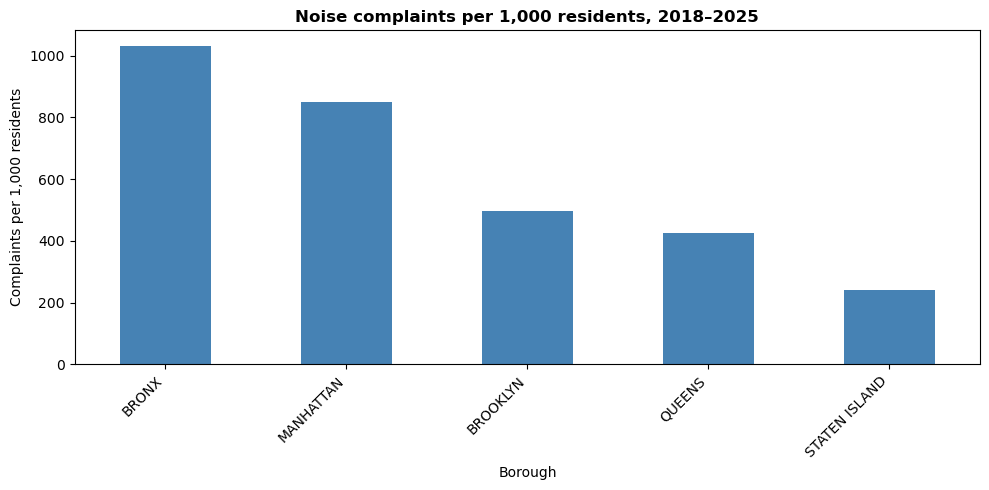

In [20]:
# 2020 US Census borough populations, used for per-capita rates in Q2
borough_pop = {
    'BRONX':         1_472_654,
    'BROOKLYN':      2_736_074,
    'MANHATTAN':     1_694_251,
    'QUEENS':        2_405_464,
    'STATEN ISLAND':   495_747,
}
# Per-capita complaint rate by borough
borough_counts = df['Borough'].value_counts()
borough_df = pd.DataFrame({
    'Complaints': borough_counts,
    'Population': [borough_pop[b] for b in borough_counts.index],
})
borough_df['Per 1,000 residents'] = (
    borough_df['Complaints'] / borough_df['Population'] * 1000
).round(0).astype(int)
borough_df = borough_df.sort_values('Per 1,000 residents', ascending=False)
print("Noise complaints per 1,000 residents (2018–2025 total):")
print(borough_df.to_string())

# Plot: per-capita bar chart
fig, ax = plt.subplots(figsize=(10, 5))
borough_df['Per 1,000 residents'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Noise complaints per 1,000 residents, 2018–2025',
             fontweight='bold')
ax.set_ylabel('Complaints per 1,000 residents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:


fig = px.bar(
    borough_df,
    x=borough_df.index,
    y='Per 1,000 residents',
    labels={'x': 'Borough', 'Per 1,000 residents': 'Complaints per 1,000 residents'},
    color_discrete_sequence=['steelblue'],
    title='Noise complaints per 1,000 residents, 2018–2025'
)
fig.update_layout(xaxis_tickangle=45)
fig.write_html("../website/complaints_per_capita.html")

# Interactive maps

In [28]:

# Aggregate by borough, complaint description, and era
agg = (
    df.groupby(['Borough', 'Complaint description', 'Era'])
    .size()
    .reset_index(name='Count')
)

# Map dataframe borough names (uppercase) to geojson borough names (proper case)
borocode_map = {'1': 'Manhattan', '2': 'Bronx', '3': 'Brooklyn', '4': 'Queens', '5': 'Staten Island'}
boroname_map = {'MANHATTAN': 'Manhattan', 'BRONX': 'Bronx', 'BROOKLYN': 'Brooklyn', 'QUEENS': 'Queens', 'STATEN ISLAND': 'Staten Island'}
agg['Borough_geo'] = agg['Borough'].map(boroname_map)

import json
with open('C:/git/sda_final_project/notebook/Borough_Boundaries_20260429.geojson', 'r') as f:
    geojson = json.load(f)

import plotly.express as px

# Default filter values
desc = 'Loud Music/Party'
era = 'Pre-COVID'

filtered = agg[(agg['Complaint description'] == desc) & (agg['Era'] == era)]

fig = px.choropleth(
    filtered,
    geojson=geojson,
    locations='Borough_geo',
    featureidkey='properties.boroname',
    color='Count',
    color_continuous_scale='YlOrRd',
    labels={'Count': 'Complaints'},
    title=f'NYC Noise Complaints: {desc} ({era})'
)
fig.update_geos(fitbounds="locations", visible=False)

# Build dropdown menus with proper callback
descs = agg['Complaint description'].unique().tolist()
eras = agg['Era'].unique().tolist()

buttons_desc = []
for d in descs:
    df_d = agg[(agg['Complaint description'] == d) & (agg['Era'] == era)]
    buttons_desc.append(dict(
        label=d,
        method='update',
        args=[{'z': [df_d['Count']], 'locations': [df_d['Borough_geo']]},
               {'title': f'NYC Noise Complaints: {d} ({era})'}]))

buttons_era = []
for e in eras:
    df_e = agg[(agg['Complaint description'] == desc) & (agg['Era'] == e)]
    buttons_era.append(dict(
        label=e,
        method='update',
        args=[{'z': [df_e['Count']], 'locations': [df_e['Borough_geo']]},
               {'title': f'NYC Noise Complaints: {desc} ({e})'}]))


# 2. Refined Layout
fig.update_layout(
    height=1550, # Make the map physically larger
    margin={"r":20, "t":20, "l":20, "b":20}, # Larger top margin (t=150) for the menus
    updatemenus=[
        dict(
            buttons=buttons_desc,
            direction='down',
            showactive=True,
            x=0.05, 
            xanchor='left',
            y=1.18,      # Move higher into the top margin
            yanchor='top', # Anchor at the top so it stays put
            bgcolor='white'
        ),
        dict(
            buttons=buttons_era,
            direction='down',
            showactive=True,
            x=0.45, 
            xanchor='left',
            y=1.18,      # Move higher into the top margin
            yanchor='top',
            bgcolor='white'
        )
    ],
    annotations=[
        dict(text='<b>Complaint Type:</b>', x=0.05, y=1.25, xref='paper', yref='paper', showarrow=False, align='left'),
        dict(text='<b>Era:</b>', x=0.45, y=1.25, xref='paper', yref='paper', showarrow=False, align='left')
    ]
)

fig.write_html("../website/interactive_noise_map.html")

More Interactive plot

In [8]:
import pandas as pd
import plotly.express as px
import json
from shapely.geometry import Point, shape
from shapely.strtree import STRtree
import numpy as np

# ============================================
# 1. Load & Process Neighborhoods
# ============================================
with open('NYC_Neighborhoods.geojson', 'r') as f:
    nta_geojson = json.load(f)

# Build spatial index for mapping 311 points to NTA names
nta_geoms = [shape(f['geometry']) for f in nta_geojson['features']]
nta_names_list = [f['properties']['NTAName'] for f in nta_geojson['features']]
tree = STRtree(nta_geoms)

def find_neighborhood(lat, lon):
    point = Point(lon, lat)
    idx = tree.nearest(point)
    if isinstance(idx, (int, np.integer)):
        return nta_names_list[idx] if nta_geoms[idx].contains(point) else None
    return None

# ============================================
# 2. Process 311 Data
# ============================================
# (Assuming 'df' is your loaded dataframe)
df['Year'] = df['Created Date'].dt.year

# Filter for top noise types to keep the HTML file size reasonable
top_noise_types = df['Complaint Type'].value_counts().nlargest(5).index.tolist()
df_filtered = df[df['Complaint Type'].isin(top_noise_types)].copy()

# Map coordinates to neighborhoods
df_filtered['Neighborhood'] = df_filtered.apply(
    lambda r: find_neighborhood(r['Latitude'], r['Longitude']), axis=1
)
df_mapped = df_filtered.dropna(subset=['Neighborhood']).copy()

# Aggregate by Neighborhood, Year, and Complaint Type
agg = (
    df_mapped.groupby(['Neighborhood', 'Year', 'Complaint Type'])
    .size()
    .reset_index(name='Count')
)

# ============================================
# 3. Create Interactive Map (The HTML Component)
# ============================================
# We create a frame for every Year + Complaint Type combination
fig = px.choropleth_mapbox(
    agg,
    geojson=nta_geojson,
    locations='Neighborhood',
    featureidkey="properties.NTAName",
    color='Count',
    animation_frame='Year',
    hover_name='Neighborhood',
    color_continuous_scale="Viridis",
    range_color=[0, agg['Count'].quantile(0.95)], # Prevents outliers from washing out the map
    mapbox_style="carto-positron",
    zoom=9.5,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    labels={'Count': 'Complaints'},
    title='NYC Noise Complaints by Neighborhood'
)

# ============================================
# 4. Add "Pick a Noise Type" Dropdown
# ============================================
# This adds a dropdown menu inside the HTML file
unique_types = agg['Complaint Type'].unique()
buttons = []

for n_type in unique_types:
    buttons.append(dict(
        method="restyle",
        label=n_type,
        args=[{"z": [agg[agg['Complaint Type'] == n_type]['Count']]}]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.1,
        y=1.15
    )],
    margin={"r":0,"t":40,"l":0,"b":0}
)

# Save to HTML
fig.write_html('../website/noise_map_interactive.html')
print("Static HTML component saved.")

Static HTML component saved.
